# Retail Rocket: Recommender models

## 1. Introduction

This notebook builds the two recommender techniques on the processed Retail Rocket data from notebook 03. The models are implemented from scratch using only numpy, pandas and scikit-learn, so no dedicated recommender library is used. The order is: first matrix factorization (SVD, technique A), then an extension of it (SVD++), and finally item-based collaborative filtering (Item-KNN, technique D), which is evaluated both as a rating prediction and as a classification task. The structure follows the Diginetica modelling notebook so the two datasets can be compared, but the user unit here is the visitor rather than the session, and the proxy rating runs over three event types instead of two.

The model is trained with stochastic gradient descent (SGD), which updates the parameters after each individual interaction, rather than batch gradient descent, which would process all interactions before making a single update. SGD is the standard optimization method for this type of matrix factorization model, as described by Koren et al. (2009). The underlying model itself, baseline predictors with latent factors, was presented in the lecture (Bhaumik, 2024b), while SGD is the training method introduced in that paper. SGD also fits the data well for two reasons: the dataset is large, so updating after every interaction converges faster than waiting for a full pass, and each interaction only involves one visitor and one item, so SGD updates exactly the few parameters that are relevant while leaving the rest untouched. This matches the very sparse structure of the interaction matrix.

### 1.1 Load the processed interactions

I load the cleaned interaction file that was saved at the end of the Retail Rocket EDA notebook. This file already contains the proxy rating, the purchase label, and the encoded visitor and item indices, so no cleaning has to be repeated here.

In [1]:
import numpy as np
import pandas as pd

# Load the cleaned interactions produced by notebook 03.
inter = pd.read_parquet("retailrocket_interactions.parquet")

# Number of visitors and items, taken from the encoded indices (0..n-1).
n_users = int(inter['user_idx'].max()) + 1
n_items = int(inter['item_idx'].max()) + 1

print("Interactions:", len(inter))
print("Visitors:", n_users, "| Items:", n_items)
print(inter.head())

Interactions: 589168
Visitors: 102292 | Items: 65144
   user_id  item_id  rating  purchased  user_idx  item_idx
0        0    67045     1.0          0         0         0
1        0   285930     1.0          0         0         1
2        0   357564     1.0          0         0         2
3        2   216305     1.0          0         1         3
4        2   259884     1.0          0         1         4


### 1.2 Train, validation and test split

To measure how well the models predict unseen interactions, the data is split into a training set, a validation set and a test set. The training set is used to fit the models, the validation set is used to tune the settings, and the test set is only used for the final scores.

The split is made per visitor rather than fully at random. For each visitor, its interactions are shuffled and divided over the three sets, so that every visitor appears in all three. This is important because the models can only predict for visitors and items they have seen during training. A purely random split could place all interactions of a low-activity visitor in one set, leaving that visitor with no training data. Splitting per visitor avoids this and matches the splitting approach used on the other dataset. Every visitor is given at least one validation interaction and one test interaction, with the remaining interactions assigned to training, and because every retained visitor has at least three interactions (guaranteed by the filtering in the EDA notebook) all three sets can always be filled. Unlike the Diginetica notebook, the split is written in a vectorized form instead of a per-visitor loop, because this dataset is larger and a loop over all visitors would be slow.

In [2]:
# Shuffle all interactions once, so each visitor's rows end up in random order.
shuffled = inter.sample(frac=1, random_state=42).reset_index(drop=True)

# Per visitor: total number of interactions (n) and the position of each row within its visitor (0..n-1).
n_per_user = shuffled.groupby('user_idx')['item_idx'].transform('size')
pos = shuffled.groupby('user_idx').cumcount()

# Aim for 10% in validation and 10% in test, but always at least 1 each (same rule as Diginetica).
n_val = np.maximum(1, (n_per_user * 0.1).astype(int))
n_test = np.maximum(1, (n_per_user * 0.1).astype(int))
n_train = n_per_user - n_val - n_test

# Assign each row to a set based on its position within the visitor:
# positions [0, n_train) -> train, [n_train, n_train+n_val) -> validation, the rest -> test.
where = np.where(pos < n_train, 'train',
         np.where(pos < n_train + n_val, 'val', 'test'))

train_df = shuffled[where == 'train'].reset_index(drop=True)
val_df = shuffled[where == 'val'].reset_index(drop=True)
test_df = shuffled[where == 'test'].reset_index(drop=True)

# Report the resulting sizes and the actual proportions.
total = len(train_df) + len(val_df) + len(test_df)
print("Train:", len(train_df), f"({len(train_df)/total:.1%})")
print("Validation:", len(val_df), f"({len(val_df)/total:.1%})")
print("Test:", len(test_df), f"({len(test_df)/total:.1%})")

# Global average rating on the training set (used as the baseline in the model).
mu = train_df['rating'].mean()
print("Global average rating (mu):", round(mu, 4))

Train: 365050 (62.0%)
Validation: 112059 (19.0%)
Test: 112059 (19.0%)
Global average rating (mu): 1.093


### Interpretation

The per-visitor split gives 62.0% of the interactions to training, 19.0% to validation and 19.0% to test. That is not the standard 80/10/10, and the reason is the many low-activity visitors: if a visitor only has three interactions, the only way to fill all three sets is one each, which pushes the validation and test shares above 10%. The training set still holds most of the data, and with about 112,000 interactions each, the validation and test sets are more than big enough to tune and evaluate the models.

The overall average rating on the training set is 1.093, very close to 1. This matches the imbalance I found in the EDA: almost all interactions are views (rating 1), with only a small share of add-to-carts (2) and transactions (3) lifting the average just above 1. This low average is the baseline the SVD model starts from before it adds the visitor and item effects.

## 2. Technique A: Matrix Factorization (SVD)

### 2.1 The model

The SVD model predicts a rating for a visitor–item pair as the sum of three parts: the global average rating, a bias for the visitor, a bias for the item, and the interaction between their latent factors (k). In formula form the prediction is:

`r_hat(u, i) = mu + b_u + b_i + p_u · q_i`

Here `mu` is the global average, `b_u` and `b_i` are the visitor and item biases (how much they differ from the average), and `p_u` and `q_i` are latent factor vectors that capture hidden patterns, as explained in the lecture on baseline predictors and matrix factorization. The model learns these values by minimizing the squared error between the predicted and the real ratings, with a regularization term that keeps the values small to avoid overfitting. Training is done with stochastic gradient descent, which updates the values one interaction at a time.

In [3]:
# Hyperparameters for the model. These are chosen as common starting values and can be tuned on the validation set.
n_factors = 20      # number of latent factors (k) per visitor and item
lr = 0.01           # learning rate (step size of each update)
reg = 0.05          # regularization strength (penalty on large values)
n_epochs = 15       # number of passes over the training data

# Initialize the parameters.
init_rng = np.random.default_rng(0)
# Small random latent factors (k) for visitors (P) and items (Q).
P = init_rng.normal(0, 0.1, (n_users, n_factors))
Q = init_rng.normal(0, 0.1, (n_items, n_factors))
# Biases start at zero.
b_u = np.zeros(n_users)
b_i = np.zeros(n_items)

print("P shape (visitors x factors):", P.shape)
print("Q shape (items x factors):", Q.shape)

P shape (visitors x factors): (102292, 20)
Q shape (items x factors): (65144, 20)


### Interpretation

The visitor factor matrix P has shape (102,292 × 20) and the item factor matrix Q has shape (65,144 × 20), which matches the number of visitors and items and the 20 latent factors I chose. So, every visitor and item has its own factor vector, and both biases start at zero. That tells me the parameters are set up correctly before training.

### 2.2 Training function

The training is wrapped in a function so it can be reused with different settings. The function builds the model from scratch: it initializes the visitor and item biases at zero and the latent factors (k) as small random values, then improves them with stochastic gradient descent. For each interaction it computes the prediction error and nudges the biases and factors a small step in the direction that reduces that error, with a regularization term that keeps the values small to prevent overfitting. The function returns the learned parameters and the validation RMSE after the final epoch, which is used in the next section to compare different numbers of latent factors (k).

The model is trained with stochastic gradient descent (SGD), which updates the parameters after each individual interaction, rather than batch gradient descent, which would process all interactions before making a single update. SGD is the standard optimization method for this type of matrix factorization model, following the baseline-plus-factors formulation of Koren et al. (2009), which is also the basis of the SVD model presented in the lecture. It also fits the data well for two reasons: the dataset is large, so updating after every interaction converges faster than waiting for a full pass, and each interaction only involves one visitor and one item, so SGD updates exactly the few parameters that are relevant while leaving the rest untouched. This matches the very sparse structure of the interaction matrix.

In [4]:
# Overall average rating on the training set. This is the baseline that the model starts from before adding the visitor bias, item bias and latent factors (k).
mu = train_df['rating'].mean()

# Put the training columns into plain numpy arrays for speed.
u_arr = train_df['user_idx'].to_numpy()
i_arr = train_df['item_idx'].to_numpy()
r_arr = train_df['rating'].to_numpy(dtype=float)


def train_svd(n_factors, lr=0.01, reg=0.05, n_epochs=15, seed=0, verbose=False):
    """Train an SVD model from scratch with stochastic gradient descent.
    Returns the learned biases, latent factors (k), and the final validation RMSE."""

    # Initialize parameters. Biases start at zero; latent factors (k) start small and random.
    init_rng = np.random.default_rng(seed)
    P = init_rng.normal(0, 0.1, (n_users, n_factors))   # visitor factors
    Q = init_rng.normal(0, 0.1, (n_items, n_factors))   # item factors
    b_u = np.zeros(n_users)                             # visitor biases
    b_i = np.zeros(n_items)                             # item biases

    # Helper to predict ratings for arrays of visitors and items.
    # Predictions are clipped to the rating range (1 = view, 2 = add-to-cart, 3 = transaction).
    def predict(u, i):
        pred = mu + b_u[u] + b_i[i] + np.sum(P[u] * Q[i], axis=1)
        return np.clip(pred, 1.0, 3.0)

    # Helper to compute RMSE on a dataframe.
    def rmse(df):
        p = predict(df['user_idx'].to_numpy(), df['item_idx'].to_numpy())
        return np.sqrt(np.mean((df['rating'].to_numpy() - p) ** 2))

    # Training loop: several passes (epochs) over all interactions.
    train_rng = np.random.default_rng(seed + 1)
    for epoch in range(n_epochs):
        order = train_rng.permutation(len(u_arr))   # shuffle order each epoch
        for idx in order:
            uu, ii = u_arr[idx], i_arr[idx]
            # Prediction error for this single interaction.
            pred = mu + b_u[uu] + b_i[ii] + P[uu] @ Q[ii]
            err = r_arr[idx] - pred
            # Update biases.
            b_u[uu] += lr * (err - reg * b_u[uu])
            b_i[ii] += lr * (err - reg * b_i[ii])
            # Update latent factors (k) (keep old P value to update Q correctly).
            Pu = P[uu].copy()
            P[uu] += lr * (err * Q[ii] - reg * P[uu])
            Q[ii] += lr * (err * Pu - reg * Q[ii])
        if verbose:
            print(f"  epoch {epoch + 1:2d} | train RMSE: {rmse(train_df):.4f} | val RMSE: {rmse(val_df):.4f}")

    # Return everything needed to make predictions later, plus the final val RMSE.
    return {'P': P, 'Q': Q, 'b_u': b_u, 'b_i': b_i,
            'predict': predict, 'val_rmse': rmse(val_df)}

### 2.3 Choosing the number of latent factors (k)

The number of latent factors (k) controls how detailed the model is. Too few factors cannot capture enough patterns (underfitting), while too many can start to model noise (overfitting). To choose a good value, the model is trained with several numbers of factors and each one is scored on the validation set, which was not used for training. The value with the lowest validation RMSE is selected and used for the final model.

To keep this search fast, a smaller number of epochs is used here than for the final model. The goal of the search is only to compare the factor sizes against each other, not to fully train each one, so a shorter training run is enough to see which factor size performs best. The selected factor size is then trained more thoroughly in the next section.

In [5]:
# Try several numbers of latent factors (k) and keep the validation RMSE for each.
# A shorter training run (fewer epochs) is used here, because the search only needs to compare the factor sizes, not fully train each model.
factor_values = [5, 10, 20, 40, 60, 80, 100]
grid_results = []

for k in factor_values:
    model_k = train_svd(n_factors=k, n_epochs=10)
    grid_results.append({'n_factors': k, 'val_rmse': model_k['val_rmse']})
    print(f"n_factors={k:3d} | val RMSE: {model_k['val_rmse']:.4f}")

# Put the results in a table and pick the number of factors with the lowest val RMSE.
grid_df = pd.DataFrame(grid_results)
best_k = int(grid_df.loc[grid_df['val_rmse'].idxmin(), 'n_factors'])
print("\nBest number of factors:", best_k)

n_factors=  5 | val RMSE: 0.2968
n_factors= 10 | val RMSE: 0.2975
n_factors= 20 | val RMSE: 0.2988
n_factors= 40 | val RMSE: 0.3005
n_factors= 60 | val RMSE: 0.3027
n_factors= 80 | val RMSE: 0.3045
n_factors=100 | val RMSE: 0.3062

Best number of factors: 5


### Interpretation

The validation RMSE is lowest at 5 latent factors (0.2968) and rises steadily as more factors are added, up to 0.3062 at 100 factors. A small number of factors therefore already captures the useful structure in the data, and adding more factors only makes the validation performance worse. This is a clear sign of overfitting: the larger models describe the training data in more detail but generalize less well to unseen interactions. The differences are small, which shows the model is stable across factor sizes, but the trend is consistent.

This pattern is expected given the extreme sparsity of the data (about 99.99% of visitor–item pairs are unobserved). With so few observed interactions per visitor and item, there is not enough signal to estimate many latent factors reliably, so a simpler model generalizes better. Based on this result, 5 latent factors is selected for the final model.

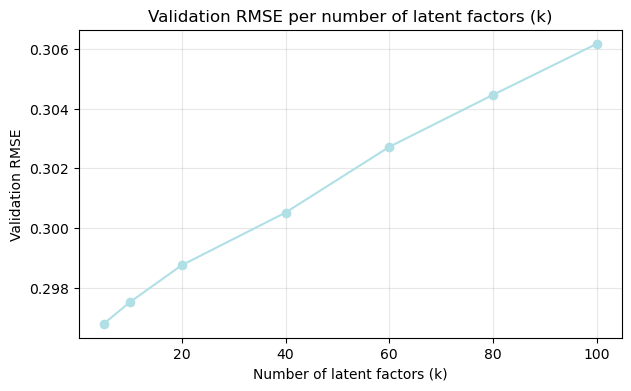

In [6]:
import matplotlib.pyplot as plt

# Plot validation RMSE against the number of latent factors (k) to show the trend.
plt.figure(figsize=(7, 4))
plt.plot(grid_df['n_factors'], grid_df['val_rmse'], marker='o', color='powderblue')
plt.xlabel('Number of latent factors (k)')
plt.ylabel('Validation RMSE')
plt.title('Validation RMSE per number of latent factors (k)')
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The plot shows the same thing as the table: the validation RMSE is lowest at 5 factors and keeps rising as I add more. There is no dip further to the right, which means adding capacity only hurts the validation performance, backing up the overfitting I saw in the table. The y-axis only covers a small range (about 0.297 to 0.306), so in absolute terms the differences are small and the model is not very sensitive to this setting. Even so, the trend is consistent enough that picking the simplest good option (5 factors) makes sense.

### 2.4 Final model and evaluation on the test set

Using the best number of factors found above, the final model is trained and then evaluated on the test set, which was not used during training or tuning. Two predictive accuracy metrics from the lecture are reported: the root mean squared error (RMSE) and the mean absolute error (MAE). Both measure how close the predicted ratings are to the real ones, where lower is better.

In [7]:
# Train the final model with the best number of factors. More epochs are used here than in the search, so the selected model is trained thoroughly before evaluation.
print(f"Training final SVD model with {best_k} factors:")
svd_model = train_svd(n_factors=best_k, n_epochs=20, verbose=True)

# Predict on the test set using the trained model.
test_pred = svd_model['predict'](test_df['user_idx'].to_numpy(),
                                 test_df['item_idx'].to_numpy())
test_true = test_df['rating'].to_numpy()

# Predictive accuracy metrics.
svd_rmse = np.sqrt(np.mean((test_true - test_pred) ** 2))
svd_mae = np.mean(np.abs(test_true - test_pred))

print("\nSVD test RMSE:", round(svd_rmse, 4))
print("SVD test MAE:", round(svd_mae, 4))

Training final SVD model with 5 factors:
  epoch  1 | train RMSE: 0.3510 | val RMSE: 0.3058
  epoch  2 | train RMSE: 0.3424 | val RMSE: 0.3030
  epoch  3 | train RMSE: 0.3358 | val RMSE: 0.3012
  epoch  4 | train RMSE: 0.3307 | val RMSE: 0.3000
  epoch  5 | train RMSE: 0.3265 | val RMSE: 0.2991
  epoch  6 | train RMSE: 0.3230 | val RMSE: 0.2986
  epoch  7 | train RMSE: 0.3197 | val RMSE: 0.2978
  epoch  8 | train RMSE: 0.3170 | val RMSE: 0.2973
  epoch  9 | train RMSE: 0.3145 | val RMSE: 0.2970
  epoch 10 | train RMSE: 0.3123 | val RMSE: 0.2968
  epoch 11 | train RMSE: 0.3103 | val RMSE: 0.2965
  epoch 12 | train RMSE: 0.3084 | val RMSE: 0.2964
  epoch 13 | train RMSE: 0.3066 | val RMSE: 0.2961
  epoch 14 | train RMSE: 0.3050 | val RMSE: 0.2960
  epoch 15 | train RMSE: 0.3035 | val RMSE: 0.2959
  epoch 16 | train RMSE: 0.3021 | val RMSE: 0.2959
  epoch 17 | train RMSE: 0.3007 | val RMSE: 0.2958
  epoch 18 | train RMSE: 0.2993 | val RMSE: 0.2958
  epoch 19 | train RMSE: 0.2982 | val RMS

### Interpretation

During training the train RMSE keeps dropping (from 0.3510 to 0.2969 over 20 epochs), while the validation RMSE falls more slowly and then flattens out around 0.2958 from about epoch 15. That gap, a train RMSE that is still going down while the validation RMSE has stalled, tells me the model has learned the useful patterns and that more training mostly fits the training data closer without helping generalization. Stopping around 20 epochs therefore seems reasonable.

On the test set the model gets an RMSE of 0.2975 and an MAE of 0.1315. Both are low on the 1-to-3 scale, so on average the predicted ratings are close to the real ones, and the test RMSE is very close to the final validation RMSE (0.2958), which suggests the model generalizes well and is not overfitting to the validation set.

I do want to read this low error carefully though. Because views (rating 1) far outnumber add-to-carts (2) and transactions (3), most true ratings are 1, and a model that predicts values near 1 is right most of the time. The low RMSE and MAE mainly show that the frequent views are predicted well, and they do not by themselves prove the model can tell the deeper events apart from views. The ranking and classification evaluations look at that.

### 2.5 Top-N ranking evaluation

RMSE and MAE measure how close the predicted ratings are to the true ratings, but a recommender system is mainly judged on whether it puts the right items at the top of its list. This is measured with rank accuracy metrics, as described in the lecture. For each visitor, the model scores all items, the items the visitor actually interacted with in the test set are held out as the relevant items, and three metrics are computed on the top-K recommendations: Precision@K, Recall@K and HitRate@K. The evaluation is run on a random sample of test visitors, which is a common approach for large datasets, and items the visitor already saw in training are excluded so the model is only credited for recommending new items.

I first evaluate at the standard K=10, which is the value used most often in the literature.

In [8]:
# For each visitor, collect the items it interacted with in train and in test.
# Train items are excluded from recommendations: test items are the "relevant" items.
train_items_per_user = train_df.groupby('user_idx')['item_idx'].apply(set)
test_items_per_user = test_df.groupby('user_idx')['item_idx'].apply(set)


def evaluate_topn(predict_scores, K=10, n_sample=2000, seed=42):
    """Evaluate top-K ranking quality on a random sample of test visitors.
    `predict_scores` is a function that returns a score for every item given a visitor.
    Returns Precision@K, Recall@K and HitRate@K averaged over the sampled visitors."""

    # Take a random sample of visitors that appear in the test set.
    eval_rng = np.random.default_rng(seed)
    test_users = test_items_per_user.index.to_numpy()
    sample = eval_rng.choice(test_users,
                             size=min(n_sample, len(test_users)),
                             replace=False)

    precisions, recalls, hits = [], [], []
    all_items = np.arange(n_items)

    for s in sample:
        relevant = test_items_per_user[s]          # items to find (ground truth)
        seen = train_items_per_user.get(s, set())  # items already known from training

        # Score every item for this visitor.
        scores = predict_scores(s, all_items)

        # Remove already-seen items by giving them a very low score.
        scores = scores.copy()
        if seen:
            scores[list(seen)] = -np.inf

        # Take the top-K item indices (highest scores first).
        top_k = np.argpartition(-scores, K)[:K]

        # Count how many of the top-K items are relevant.
        n_hit = len(set(top_k.tolist()) & relevant)

        precisions.append(n_hit / K)
        recalls.append(n_hit / len(relevant))
        hits.append(1.0 if n_hit > 0 else 0.0)

    return {'precision': np.mean(precisions),
            'recall': np.mean(recalls),
            'hitrate': np.mean(hits)}

In [9]:
# Build a scoring function for the trained SVD model: given a visitor and a list of items, return the predicted score for each item.
P = svd_model['P']
Q = svd_model['Q']
b_u = svd_model['b_u']
b_i = svd_model['b_i']

def svd_scores(user, items):
    return mu + b_u[user] + b_i[items] + Q[items] @ P[user]

# Run the top-N evaluation for the SVD model at K = 10.
svd_topn = evaluate_topn(svd_scores, K=10)

print("SVD Precision@10:", round(svd_topn['precision'], 4))
print("SVD Recall@10:   ", round(svd_topn['recall'], 4))
print("SVD HitRate@10:  ", round(svd_topn['hitrate'], 4))

SVD Precision@10: 0.0
SVD Recall@10:    0.0
SVD HitRate@10:   0.0


### Interpretation

At K=10 all three ranking metrics are 0.0: not a single held-out item shows up in the top 10. On its own this is hard to read, because the catalogue is huge (about 65,000 items), and the chance that one specific held-out item lands in a list of only 10 is tiny even for a decent model. A 0 at K=10 does not yet tell me whether the model has any ranking ability, or whether the top-10 list is simply too strict given how many items there are.

To get a fairer picture, I repeat the evaluation for larger K. If the scores stay at 0 as K grows, the model basically has no ranking signal; if they go up, it does rank some relevant items reasonably high, just not in the top 10.

### A finer ranking evaluation

The first run used a sample of 2,000 visitors and stopped at K=100. With a catalogue of about 65,000 items, a hit rate below roughly 0.05% cannot be resolved on only 2,000 visitors, so a genuinely small ranking signal would still appear as exactly 0. To measure more precisely, the evaluation is repeated on a larger sample of 10,000 visitors and extended to larger values of K (up to 500). This does not change the evaluation rule, only its resolution: a larger sample lowers the smallest hit rate that can be detected, and the larger K values reveal whether the model ranks any relevant items highly, just deeper than the top 100. As a reference point, randomly guessing would give a hit rate of about K divided by the catalogue size, so roughly 0.15% at K=100 and 0.77% at K=500. The same settings are then used for the popularity baseline so the two stay comparable.

In [12]:
# Use a larger evaluation sample so that small hit rates can be measured instead of rounded to 0.
# The same sample size is reused for every model so they stay comparable.
N_EVAL = 10000

# Evaluate SVD ranking on a wider range of K, including larger lists.
print("SVD ranking:")
for K in [10, 20, 50, 100, 200, 500]:
    res = evaluate_topn(svd_scores, K=K, n_sample=N_EVAL)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

SVD ranking:
K= 10 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 20 | Precision: 0.0000 | Recall: 0.0002 | HitRate: 0.0002
K= 50 | Precision: 0.0000 | Recall: 0.0008 | HitRate: 0.0008
K=100 | Precision: 0.0000 | Recall: 0.0016 | HitRate: 0.0016
K=200 | Precision: 0.0000 | Recall: 0.0034 | HitRate: 0.0035
K=500 | Precision: 0.0000 | Recall: 0.0079 | HitRate: 0.0085


### Interpretation

With the bigger sample and the wider range of K, the SVD model is no longer flat at zero, but the ranking signal is still very weak. The HitRate rises slowly from 0.0 at K=10 to 0.0085 at K=500, which means that even with a list of 500 items the held-out item is found for less than 1% of visitors. The precision stays at 0.0000 throughout, because with only a few held-out items per visitor and a list that is tiny next to the 65,000-item catalogue, almost none of the top-K slots can be correct. Recall and HitRate are the metrics that actually say something here.

Comparing these numbers to random guessing puts them in context. Random guessing would give roughly K divided by the catalogue size, about 0.15% at K=100 and 0.77% at K=500. SVD gets 0.16% at K=100 and 0.85% at K=500, basically the level of random guessing, with at most a tiny edge at large K. That is a surprising result next to the low RMSE from earlier: the model predicts ratings accurately but cannot rank the right items to the top. The reason is the data, where almost everything is a view with rating 1, the model predicts something close to 1 for nearly every item and the scores are dominated by the item bias. That leaves the predicted scores very similar across items, with almost nothing to order them by, and the top-N list ends up close to random. To me this shows that a low rating error does not guarantee good recommendations, and that rating prediction and ranking really measure different things. It is also why I evaluate the item-based technique with classification metrics too, since those focus on finding the rarer deeper events instead of predicting the dominant view rating.

### 2.6 Comparison with a popularity baseline

To judge whether the SVD model actually learns useful ranking patterns, it is compared with a simple popularity baseline. This baseline ignores the visitor completely and always recommends the most popular items, measured by how many times each item was interacted with in the training set. Comparing against such a popularity baseline is a standard practice in recommender systems: the most-popular baseline ranks items by their number of interactions in the training data and is widely used as a reference, because it can be surprisingly hard to beat on sparse data despite using no personalization (Ji et al., 2020).

In [13]:
# Count how often each item appears in the training set (its popularity).
item_popularity_train = train_df['item_idx'].value_counts()

# Build a popularity score array: each item's score is its training count.
# The same score is given to every visitor, because popularity ignores the visitor.
popularity_scores = np.zeros(n_items)
popularity_scores[item_popularity_train.index.to_numpy()] = item_popularity_train.to_numpy()

# Scoring function in the same format as svd_scores, so evaluate_topn can reuse it.
# It returns the popularity score of each item, regardless of which visitor is given.
def popularity_score_fn(user, items):
    return popularity_scores[items]

# Evaluate the popularity baseline at the same K values and the same sample size as SVD.
print("Popularity baseline:")
for K in [10, 20, 50, 100, 200, 500]:
    res = evaluate_topn(popularity_score_fn, K=K, n_sample=N_EVAL)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

Popularity baseline:
K= 10 | Precision: 0.0009 | Recall: 0.0084 | HitRate: 0.0087
K= 20 | Precision: 0.0007 | Recall: 0.0127 | HitRate: 0.0133
K= 50 | Precision: 0.0006 | Recall: 0.0270 | HitRate: 0.0278
K=100 | Precision: 0.0004 | Recall: 0.0423 | HitRate: 0.0436
K=200 | Precision: 0.0003 | Recall: 0.0650 | HitRate: 0.0670
K=500 | Precision: 0.0002 | Recall: 0.1145 | HitRate: 0.1175


### Interpretation

The popularity baseline clearly beats SVD on ranking at every K. At K=100 the baseline gets a HitRate of 0.0436 against 0.0016 for SVD, and at K=500 it reaches 0.1175 against only 0.0085, which means just recommending the most popular items finds the held-out item about fourteen times more often than the trained model does. The baseline also stays above the random-guessing level at every K (for example 0.0436 at K=100 against a random rate of about 0.15%), which SVD does not.

This tells me two things at once. First, the evaluation works: a model with real ranking signal does produce non-zero scores through the same `evaluate_topn` function, which means SVD's very low score is genuine and not a bug. Second, SVD adds basically no ranking value here and even falls below a trivial popularity rule. Because almost all interactions are views with the same rating, the model has little signal to tell items apart, and its ranking sits close to random. I see this as a useful insight rather than a failed implementation: on sparse, view-dominated e-commerce data a rating-based matrix factorization model is good at predicting ratings but weak at ranking, and a simple popularity heuristic beats it comfortably. It also gives me a clear reference point for the item-based technique, which I compare against both SVD and this baseline.

### 2.7 Example top-N recommendations

To make the model's output concrete, the top-10 recommendations are generated for two example visitors: a randomly chosen visitor and the most active visitor (the one with the most interactions in the training set). For each visitor, the items it actually interacted with are shown next to the items the model recommends, so the two can be compared.

Because Retail Rocket items are anonymized, there are no readable product names. To still give some context, each item is shown with its category id, which is read from the item_properties files here. This category is used only to inspect the recommendations, not as a model feature, which keeps the modelling purely interaction-based as decided in the EDA notebook. Unlike Diginetica, the dataset has no price column, so price is not shown.

In [14]:
# Load item categories from the item_properties files, for inspecting recommendations only.
prop1 = pd.read_csv("retailrocket/item_properties_part1.csv")
prop2 = pd.read_csv("retailrocket/item_properties_part2.csv")
props = pd.concat([prop1, prop2], ignore_index=True)

# Keep only the rows describing an item's category, and take the most recent category per item.
cats = props[props['property'] == 'categoryid'].copy()
cats = cats.sort_values('timestamp').drop_duplicates('itemid', keep='last')
item_to_category = cats.set_index('itemid')['value']

# Reverse map from the encoded item index back to the original item_id.
idx_to_item = (inter[['item_idx', 'item_id']]
               .drop_duplicates()
               .set_index('item_idx')['item_id'])

# Helper: turn a list of item indices into a readable table with the item's category.
def describe_items(item_indices):
    rows = []
    for idx in item_indices:
        original_id = idx_to_item[idx]
        cat = item_to_category.get(original_id, None)   # category id, or None if unknown
        rows.append({'item_idx': idx, 'item_id': original_id, 'category_id': cat})
    return pd.DataFrame(rows)

In [16]:
def recommend_for_user(user, K=10):
    """Return the top-K recommended item indices for one visitor,
    excluding items the visitor already interacted with in training."""
    all_items = np.arange(n_items)
    scores = svd_scores(user, all_items)        # score every item

    # Exclude items already seen in training, so only new items are recommended.
    seen = train_items_per_user.get(user, set())
    if seen:
        scores[list(seen)] = -np.inf

    # Take the top-K items, highest score first.
    top_k = np.argpartition(-scores, K)[:K]
    top_k = top_k[np.argsort(-scores[top_k])]
    return top_k


def show_user(user, K=10):
    """Print what a visitor interacted with in training and what the model recommends."""
    seen = sorted(train_items_per_user.get(user, set()))
    print(f"Visitor {user} interacted with {len(seen)} items in training.")
    print("\nItems this visitor interacted with (first 10):")
    print(describe_items(seen[:10]).to_string(index=False))
    print("\nTop-10 recommendations from SVD:")
    print(describe_items(recommend_for_user(user, K)).to_string(index=False))

In [17]:
# Example 1: a randomly chosen visitor from the test set.
example_rng = np.random.default_rng(7)
random_user = int(example_rng.choice(test_items_per_user.index.to_numpy()))

print("=== Example 1: random visitor ===")
show_user(random_user)

=== Example 1: random visitor ===
Visitor 96656 interacted with 4 items in training.

Items this visitor interacted with (first 10):
 item_idx  item_id category_id
     5890   172293         984
     7990   294242         984
     9540   309652        1197
    16641   183178         984

Top-10 recommendations from SVD:
 item_idx  item_id category_id
    25292   387504        1493
    34693   132633        1685
    25291   297931        1493
     9784    31239         126
     6451   424245        1349
    30958   258600         228
    63335    57946        1317
    50160    28789        1685
    18543   195423         421
    39090   297145        1493


### Interpretation

This randomly chosen visitor interacted with four items, three of them from category 984 and one from category 1197. The ten items recommended by SVD come from a wide spread of other categories (1493, 1685, 126, 228, and so on) and none of them match the categories the visitor actually interacted with. The recommendations are not clearly tailored to this visitor.

This fits the ranking results from the previous sections: because the visitor has very few interactions and almost all of them are views, the model has little visitor-specific signal to work with, so its recommendations fall back on broadly popular-looking items rather than items related to this visitor's history.

In [18]:
# Example 2: the most active visitor (most interactions in the training set).
most_active_user = int(train_df['user_idx'].value_counts().idxmax())

print("=== Example 2: most active visitor ===")
show_user(most_active_user)

=== Example 2: most active visitor ===
Visitor 83857 interacted with 2864 items in training.

Items this visitor interacted with (first 10):
 item_idx  item_id category_id
        7    65273         342
        8   253615         342
       20   319680         858
       29   224700         317
       43   291964        1273
       47   134620         589
       51   373637        1051
       52     1152        1051
       55   305656        1051
       57    84310        1051

Top-10 recommendations from SVD:
 item_idx  item_id category_id
    25292   387504        1493
    34693   132633        1685
    25291   297931        1493
     9784    31239         126
     6451   424245        1349
    39090   297145        1493
    50160    28789        1685
    21991   176669         686
    63335    57946        1317
    12031   369053        1493


### Interpretation

The most active visitor is very different from the random one: it interacted with 2,864 items, with a clear concentration in category 1051 (four of its first ten items). This is a strong and clear preference signal, and a good recommender would be expected to suggest more items from category 1051 or closely related categories.

However, the top-10 recommendations contain no items from category 1051; they come from the same spread of categories as before (1493, 1685, 126, and others). In fact, the recommendations are almost identical to those given to the random visitor, with the same items such as 387504, 132633 and 297931 appearing in both lists in nearly the same order. This is a concrete illustration of the earlier finding that the SVD model does not rank items in a visitor-specific way on this data: even when a visitor shows a very clear category preference across thousands of interactions, the model does not reflect that preference and instead recommends the same small set of generally well-connected items to everyone. It is the clearest single piece of evidence that the low RMSE does not translate into useful, personalized recommendations.

## 3. Technique A (bonus): SVD++

### 3.1 The model

SVD++ is an extension of the SVD model that also uses implicit feedback. The idea, introduced by Koren et al. (2009), is that the items a visitor interacted with already say something about that visitor, regardless of the exact rating given. In addition to the visitor factor vector, the model learns an implicit factor vector for every item, and a visitor is then represented by its own factors plus the average of the implicit factors of all items it interacted with.

The prediction becomes:

`r_hat(u, i) = mu + b_u + b_i + q_i · ( p_u + |N(u)|^(-1/2) · sum over j in N(u) of y_j )`

Here `N(u)` is the set of items the visitor interacted with, and `y_j` is the implicit factor vector of item j. The term `|N(u)|^(-1/2)` normalizes for the number of items in the visitor's history, so that very active visitors do not dominate. All other parts are the same as in the SVD

In [19]:
# Build, for each visitor, the list of item indices it interacted with in training.
user_items = train_df.groupby('user_idx')['item_idx'].apply(lambda s: s.to_numpy())

# Convert to a plain dict for fast lookup during training.
Nu = {u: items for u, items in user_items.items()}

print("Visitors with implicit feedback:", len(Nu))
print("Example - items of visitor 0:", Nu[0][:10])

Visitors with implicit feedback: 102292
Example - items of visitor 0: [2]


### Interpretation

The implicit-feedback lookup covers all 102,292 visitors, matching the number of visitors in the data, so every visitor has its own interaction history for the SVD++ term. The example shows visitor 0 with a single training item, which is expected: for a visitor with three interactions, the split sends one interaction to validation and one to test, leaving one in training.

In [20]:
def train_svdpp(n_factors=10, lr=0.01, reg=0.05, n_epochs=15, seed=0, verbose=False):
    """Train an SVD++ model from scratch with stochastic gradient descent.
    Adds an implicit-feedback term on top of the standard SVD model."""

    # Initialize parameters. P, Q and the biases are as in SVD; Y holds the
    # implicit item factors used by the SVD++ term.
    init_rng = np.random.default_rng(seed)
    P = init_rng.normal(0, 0.1, (n_users, n_factors))    # visitor factors
    Q = init_rng.normal(0, 0.1, (n_items, n_factors))    # item factors
    Y = init_rng.normal(0, 0.1, (n_items, n_factors))    # implicit item factors
    b_u = np.zeros(n_users)
    b_i = np.zeros(n_items)

    # Plain numpy arrays of the training interactions, for speed.
    u_arr = train_df['user_idx'].to_numpy()
    i_arr = train_df['item_idx'].to_numpy()
    r_arr = train_df['rating'].to_numpy(dtype=float)

    train_rng = np.random.default_rng(seed + 1)
    for epoch in range(n_epochs):
        order = train_rng.permutation(len(u_arr))
        for idx in order:
            uu, ii, r = u_arr[idx], i_arr[idx], r_arr[idx]

            # Implicit feedback part: average of the implicit factors of all items
            # this visitor interacted with, scaled by 1/sqrt(number of items).
            items_u = Nu[uu]
            sqrt_n = 1.0 / np.sqrt(len(items_u))
            y_sum = Y[items_u].sum(axis=0)
            implicit = sqrt_n * y_sum

            # The visitor representation is its own factors plus the implicit part.
            u_factor = P[uu] + implicit

            # Prediction and error for this interaction.
            pred = mu + b_u[uu] + b_i[ii] + Q[ii] @ u_factor
            err = r - pred

            # Update the biases.
            b_u[uu] += lr * (err - reg * b_u[uu])
            b_i[ii] += lr * (err - reg * b_i[ii])

            # Update the visitor and item factors.
            Qi = Q[ii].copy()
            P[uu] += lr * (err * Qi - reg * P[uu])
            Q[ii] += lr * (err * u_factor - reg * Qi)

            # Update the implicit item factors for every item in the visitor's history.
            Y[items_u] += lr * (err * sqrt_n * Qi - reg * Y[items_u])

        if verbose:
            print(f"  epoch {epoch + 1:2d} done")

    return {'P': P, 'Q': Q, 'Y': Y, 'b_u': b_u, 'b_i': b_i}

### 3.2 Training and evaluation

The SVD++ model is trained with the same number of latent factors as the final SVD model and the same settings, so that the two models can be compared fairly. After training, the model is evaluated on the test set with the same predictive accuracy metrics (RMSE and MAE) and the same top-N ranking metrics used for SVD. Using identical settings and metrics isolates the effect of the added implicit-feedback term.

In [21]:
# Train the final SVD++ model with the same number of factors as the final SVD model.
print("Training SVD++ model:")
svdpp_model = train_svdpp(n_factors=best_k, n_epochs=15, verbose=True)

# Unpack the learned parameters.
P_pp = svdpp_model['P']
Q_pp = svdpp_model['Q']
Y_pp = svdpp_model['Y']
b_u_pp = svdpp_model['b_u']
b_i_pp = svdpp_model['b_i']

print("Training done.")

Training SVD++ model:
  epoch  1 done
  epoch  2 done
  epoch  3 done
  epoch  4 done
  epoch  5 done
  epoch  6 done
  epoch  7 done
  epoch  8 done
  epoch  9 done
  epoch 10 done
  epoch 11 done
  epoch 12 done
  epoch 13 done
  epoch 14 done
  epoch 15 done
Training done.


In [22]:
# Helper: build the full visitor representation (own factors + implicit part) for a single visitor, as used in the SVD++ prediction.
def svdpp_user_vector(user):
    items_u = Nu[user]
    implicit = Y_pp[items_u].sum(axis=0) / np.sqrt(len(items_u))
    return P_pp[user] + implicit

# Predict ratings for the test set, one row at a time (clipped to the 1-3 range).
test_pred_pp = []
for u, i in zip(test_df['user_idx'].to_numpy(), test_df['item_idx'].to_numpy()):
    pred = mu + b_u_pp[u] + b_i_pp[i] + Q_pp[i] @ svdpp_user_vector(u)
    test_pred_pp.append(pred)
test_pred_pp = np.clip(test_pred_pp, 1.0, 3.0)
test_true = test_df['rating'].to_numpy()

# Predictive accuracy metrics.
svdpp_rmse = np.sqrt(np.mean((test_true - test_pred_pp) ** 2))
svdpp_mae = np.mean(np.abs(test_true - test_pred_pp))

print("SVD++ test RMSE:", round(svdpp_rmse, 4))
print("SVD++ test MAE:", round(svdpp_mae, 4))
print("(SVD test RMSE was:", round(svd_rmse, 4), "| MAE:", round(svd_mae, 4), ")")

SVD++ test RMSE: 0.2978
SVD++ test MAE: 0.1332
(SVD test RMSE was: 0.2975 | MAE: 0.1315 )


### Interpretation

On the predictive accuracy metrics, SVD++ performs almost identically to plain SVD: an RMSE of 0.2978 against 0.2975, and an MAE of 0.1332 against 0.1315. The difference is tiny and even slightly in favour of plain SVD, which means the implicit-feedback term did not improve the rating prediction on this dataset.

I think this makes sense given the data. The implicit-feedback term in SVD++ is meant to add information about which items a visitor interacted with, on top of the ratings. Here that information is already mostly captured by the ratings themselves: almost every interaction is a view with rating 1, so knowing that a visitor interacted with an item adds little beyond what the rating already says. In a dataset with richer or more varied feedback the implicit term would probably help more. On this view-dominated data its added value is minimal, which is a useful finding in itself: the more complex model is not always better, and its benefit depends on how much extra information the implicit feedback actually carries.

In [23]:
# Scoring function for SVD++, in the same format as svd_scores, so the same top-N evaluation function can be reused.
def svdpp_scores(user, items):
    return mu + b_u_pp[user] + b_i_pp[items] + Q_pp[items] @ svdpp_user_vector(user)

# Run the top-N ranking evaluation at the same K values and sample size used for SVD.
print("SVD++ ranking:")
for K in [10, 20, 50, 100, 200, 500]:
    res = evaluate_topn(svdpp_scores, K=K, n_sample=N_EVAL)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

SVD++ ranking:
K= 10 | Precision: 0.0000 | Recall: 0.0000 | HitRate: 0.0000
K= 20 | Precision: 0.0000 | Recall: 0.0005 | HitRate: 0.0005
K= 50 | Precision: 0.0000 | Recall: 0.0016 | HitRate: 0.0017
K=100 | Precision: 0.0000 | Recall: 0.0026 | HitRate: 0.0027
K=200 | Precision: 0.0000 | Recall: 0.0044 | HitRate: 0.0045
K=500 | Precision: 0.0000 | Recall: 0.0098 | HitRate: 0.0106


### Interpretation

The ranking results for SVD++ are almost the same as for plain SVD. The HitRate stays at 0.0 for K=10 and reaches only 0.0106 at K=500, against 0.0085 for SVD at the same K. That is a marginal improvement at the widest list, but the scores stay at roughly the level of random guessing (about 0.77% at K=500) and far below the popularity baseline (0.1175 at K=500). The implicit-feedback term therefore does not meaningfully improve ranking either.

This lines up with the rating evaluation. On this view-dominated data the implicit feedback that SVD++ adds carries little extra information beyond what is already in the ratings, which means it changes neither the rating accuracy nor the ranking quality in any real way. The underlying limitation is the same for both models: with almost all interactions being views with the same rating, there is very little signal to tell items apart, so neither model can rank the relevant items to the top.

### 3.3 Conclusion: SVD and SVD++

Technique A came down to two models I built from scratch and trained with SGD (Koren et al., 2009): plain SVD and the SVD++ extension. Their rating accuracy was good on paper, with a test RMSE around 0.298 and MAE around 0.13, but the ranking results told a different story, where both sat near random and lost heavily to the popularity baseline.

What I found most telling is how little SVD++ added. The whole point of its implicit-feedback term is to use which items a visitor touched, on top of the rating. On this data that barely helped, because the rating already encodes almost the same thing: with the funnel running view, add-to-cart, transaction but views making up nearly everything, knowing that a visitor interacted with an item says little beyond the rating itself. So, the extra parameters mostly added cost without payoff, and SVD++ landed almost exactly where SVD did.

The takeaway from technique A is therefore less about which model wins and more about the ceiling the data sets. A low rating error does not translate into useful recommendations here, and reaching for a more complex model is not a fix when the limiting factor is how thin and view-heavy the feedback is. That ceiling is the thing the item-based technique and the cross-dataset comparison test next.

## 4. Technique D: Item-based collaborative filtering (Item-KNN)

### 4.1 Introduction and interaction matrix

The second technique is item-based collaborative filtering (Item-KNN). Unlike SVD, which learns latent factors, Item-KNN is a neighbourhood method: it measures how similar items are based on the visitors they share, and predicts a rating for a visitor–item pair from the ratings of the most similar items the visitor has already interacted with. As described in the lecture on collaborative filtering techniques, two items are considered similar if the same visitors interacted with them in a similar way (Bhaumik, 2024b). This is a collaborative method, not a content-based one: the similarity comes from interaction patterns, not from item attributes such as category.

The technique is evaluated in two ways, as required: as a rating prediction task (predicting the proxy rating, measured with RMSE and MAE) and as a classification task (predicting whether an interaction is a transaction, measured with precision, recall, F1 and AUC-ROC).

The first step is to build a sparse item–visitor matrix from the training data. A sparse matrix is used because a dense matrix of 65,144 items by 102,292 visitors would be far too large to fit in memory, while almost all of its entries would be zero.

In [24]:
from scipy.sparse import coo_matrix

# Build a sparse interaction matrix with items as rows and visitors as columns.
# Items are the rows because Item-KNN compares items with each other.
def build_item_user_matrix(df, n_items, n_users):
    return coo_matrix(
        (df['rating'].astype('float32'),
         (df['item_idx'].astype(int), df['user_idx'].astype(int))),
        shape=(n_items, n_users)
    ).tocsr()

# Build the matrix from the training data only.
train_matrix = build_item_user_matrix(train_df, n_items, n_users)

print("Item-visitor matrix shape:", train_matrix.shape)
print("Number of observed interactions:", train_matrix.nnz)
print("Density:", f"{train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]):.6%}")

Item-visitor matrix shape: (65144, 102292)
Number of observed interactions: 365050
Density: 0.005478%


### Interpretation

The item–visitor matrix has 65,144 items as rows and 102,292 visitors as columns, with 365,050 observed interactions. These come from the training set only, which matches the size of the training split and is what I want: the similarities have to be learned from training data so the validation and test sets stay unseen. The density is only 0.0055%, which confirms again how sparse the data is. This sparsity is the main reason I use a sparse matrix format, since storing the full dense matrix would waste almost all of its space on empty entries, and it is also what makes item similarity hard to estimate, because two items rarely share many visitors.

### 4.2 Mean-centering by item

Before computing similarities, the ratings are mean-centered per item: the average rating of each item is subtracted from its observed ratings. I do this to remove the item bias, so that the similarity reflects how visitors deviate from an item's average rather than the average rating level itself. This supports the neighbourhood-based approach described in the lecture, where similarity should capture shared interaction patterns rather than overall popularity (Bhaumik, 2024b). The item means are kept as well, because they are added back when predicting a rating.

In [25]:
# Compute the average rating per item from the training data.
item_means = np.zeros(n_items, dtype=np.float32)
means_series = train_df.groupby('item_idx')['rating'].mean()
item_means[means_series.index.to_numpy()] = means_series.to_numpy(dtype=np.float32)

# Mean-center the matrix: subtract each item's mean from its non-zero ratings.
# This is done in a vectorized way using the sparse matrix structure.
train_centered = train_matrix.copy()
# row_index of every stored value, so we know which item (row) each value belongs to.
row_index = np.repeat(np.arange(n_items), np.diff(train_centered.indptr))
train_centered.data -= item_means[row_index]

print("Mean-centered matrix shape:", train_centered.shape)
print("Example item means (first 5):", item_means[:5])

Mean-centered matrix shape: (65144, 102292)
Example item means (first 5): [1.0333333 1.1538461 1.0384616 1.        1.2162162]


### Interpretation

The mean-centered matrix keeps the same shape (65,144 × 102,292), but the stored ratings are now expressed relative to each item's average. The example item means are all close to 1 (for instance 1.033, 1.154 and 1.216, with one item at exactly 1.000), which I expected: since most interactions per item are views with a rating of 1, the average rating of an item stays just above 1, lifted slightly by the occasional add-to-cart (2) or transaction (3). Subtracting these means removes the item-level bias, so the similarity computed next reflects how visitors deviate from an item's typical rating rather than the overall rating level.

### 4.3 Computing item–item similarity (top-k neighbours)

Next, the similarity between items is computed using cosine similarity on the mean-centered item vectors. A full item-by-item similarity matrix would have 65,144 × 65,144 entries, which is far too large to store. Instead, for each item only its k nearest neighbours are kept, using scikit-learn's NearestNeighbors with the cosine metric. This is both memory-efficient and in line with the lecture's point that a small number of high-confidence neighbours is preferable to many neighbours with untrustworthy similarity weights (Bhaumik, 2024b). The item vectors are first L2-normalized, so that cosine similarity reduces to a dot product.

In practice, NearestNeighbors with the cosine metric works by computing the cosine distance between an item's vector and every other item's vector, and then returning the k items with the smallest distance (the most similar ones) for each item. With `algorithm='brute'` these distances are computed directly for all item pairs rather than through an approximate index, which is exact and works well here because the vectors are sparse. This is the one place where a library is used for part of the model, so its behaviour is described explicitly. The prediction step itself is implemented from scratch.

In [26]:
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

# Normalize each item vector to unit length, so cosine similarity = dot product.
item_vectors = normalize(train_centered, norm='l2', axis=1)

# Fit a nearest-neighbours model that finds the k most similar items per item.
def fit_item_knn(vectors, k):
    # k + 1 because the closest neighbour of an item is always itself.
    model = NearestNeighbors(n_neighbors=k + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    model.fit(vectors)
    distances, indices = model.kneighbors(vectors)
    # Drop the first column (the item itself) and turn cosine distance into similarity.
    neighbor_idx = indices[:, 1:]
    neighbor_sim = 1.0 - distances[:, 1:]
    return neighbor_idx, neighbor_sim

# Fit an initial model with k = 20 neighbours as a starting point.
neighbor_idx, neighbor_sim = fit_item_knn(item_vectors, k=20)

print("Neighbour index matrix shape:", neighbor_idx.shape)
print("Neighbour similarity matrix shape:", neighbor_sim.shape)
print("Example - neighbours of item 0:", neighbor_idx[0][:5])
print("Example - their similarities:", neighbor_sim[0][:5].round(3))

Neighbour index matrix shape: (65144, 20)
Neighbour similarity matrix shape: (65144, 20)
Example - neighbours of item 0: [11900 11887   894 28050 18128]
Example - their similarities: [0.024 0.01  0.009 0.006 0.005]


### Interpretation

For each of the 65,144 items, the 20 most similar items and their similarity scores are stored, giving two matrices of shape (65,144 × 20). For item 0, the nearest neighbours have similarities of only about 0.024, 0.010, 0.009, 0.006 and 0.005. These values are positive but very close to zero, which means that even the most similar items share only a small fraction of their visitors with item 0. This matches the extreme sparsity of the matrix (density 0.0055%) and the use of the visitor rather than the session as the column unit, since two items rarely have many visitors in common.

A single item cannot be generalized on its own, but it already hints at a problem for the neighbourhood method: if the closest neighbours carry such weak similarity, there is little reliable signal to base a prediction on. Whether this holds across items is something the neighbour tuning and the evaluation will show. Keeping only the top 20 neighbours instead of the full similarity matrix keeps the computation within memory and focuses the prediction on the most relevant items, even when those are only weakly similar.

### 4.4 Rating prediction function

With the neighbours known, a rating for a visitor–item pair is predicted as follows: look at the k items most similar to the target item, keep those that the visitor has actually interacted with, and take a weighted average of their ratings (weighted by similarity), expressed relative to each item's mean. The target item's own mean is then added back. If the visitor has not interacted with any similar item, the prediction falls back to the target item's mean rating. This is the weighted neighbourhood prediction described in the lecture (Bhaumik, 2024a).

In [27]:
# The matrix is stored item x visitor, but for prediction I need a fast lookup of "did this visitor interact with this item, and with what rating".
# A visitor x item version gives fast per-visitor access.
train_by_user = train_matrix.T.tocsr()

def predict_item_knn(user, item, neighbor_idx, neighbor_sim, min_neighbors=1):
    # Neighbours of the target item and their similarities.
    neighbors = neighbor_idx[item]
    sims = neighbor_sim[item]

    # Ratings this visitor gave to all items (sparse row: dense lookup).
    user_row = train_by_user[user]
    rated_items = user_row.indices
    rated_values = user_row.data

    num, den, used = 0.0, 0.0, 0
    # Go through the neighbours and use the ones the visitor has interacted with.
    for nb, sim in zip(neighbors, sims):
        if sim <= 0:
            continue
        # Did the visitor interact with this neighbour item?
        pos = np.where(rated_items == nb)[0]
        if len(pos) == 0:
            continue
        rating = rated_values[pos[0]]
        num += sim * (rating - item_means[nb])   # weighted deviation from item mean
        den += sim
        used += 1

    # Fall back to the item mean if there is too little information.
    if used < min_neighbors or den == 0:
        return float(np.clip(item_means[item], 1.0, 3.0))
    pred = item_means[item] + num / den
    return float(np.clip(pred, 1.0, 3.0))

# Quick sanity check on a few visitor-item pairs from the training data.
for u, i in [(train_df['user_idx'].iloc[0], train_df['item_idx'].iloc[0]),
             (train_df['user_idx'].iloc[100], train_df['item_idx'].iloc[100])]:
    print(f"visitor {u}, item {i} -> predicted rating: {predict_item_knn(u, i, neighbor_idx, neighbor_sim):.3f}")

visitor 85811, item 61984 -> predicted rating: 1.000
visitor 37655, item 30525 -> predicted rating: 1.286


### Interpretation

The sanity check returns a predicted rating of 1.000 for the first pair and 1.286 for the second, which shows the two cases the function can produce. The first prediction of exactly 1.000 is a fall-back to the item mean: either the visitor had not interacted with any of the target item's neighbours, or those neighbours had a similarity of zero, so the function returns the item's average rating, which sits close to 1 because of the view dominance. The second prediction of 1.286 is the more interesting case, where the visitor had interacted with some of the neighbours and their similarity-weighted deviation from the item means lifts the prediction above 1.

Both values are low, which reflects the view dominance in the data rather than a problem with the method: most item means are just above 1, and the neighbours used in the prediction are also dominated by views, so the weighted prediction stays near 1. The prediction function itself works as intended, combining the ratings of similar items relative to their means and adding the target item's mean back. Pairs that involve an add-to-cart or a transaction would give a higher predicted value, which is checked next.

To confirm that the proxy weighting actually works, the prediction is also checked on a visitor–item pair that ends in a transaction (rating 3). If the weighting is applied correctly, the predicted rating for such a pair should be noticeably higher than for a view-only pair.

In [28]:
# Find a few training pairs that are transactions (rating == 3) to test the prediction.
transaction_pairs = train_df[train_df['rating'] == 3.0].head(3)

print("Predictions for transaction pairs (true rating = 3):")
for row in transaction_pairs.itertuples(index=False):
    pred = predict_item_knn(int(row.user_idx), int(row.item_idx),
                            neighbor_idx, neighbor_sim)
    print(f"visitor {int(row.user_idx)}, item {int(row.item_idx)} "
          f"-> predicted rating: {pred:.3f}")

Predictions for transaction pairs (true rating = 3):
visitor 101160, item 44569 -> predicted rating: 2.400
visitor 78992, item 24221 -> predicted rating: 3.000
visitor 77032, item 18630 -> predicted rating: 1.545


### Interpretation

For the three transaction pairs, the predicted ratings are clearly above 1: 2.400, 3.000 and 1.545. This confirms that the proxy weighting works as intended. Where a visitor interacted with a transaction, and the neighbouring items were also bought by similar visitors, the prediction rises well above the view level of 1 and can reach the transaction value of 3. Despite the weak neighbour similarities seen in section 4.3, these pairs have enough visitor overlap for the signal to come through.

The differences between the three pairs are also informative. The pair predicted at 3.000 is a case where the relevant neighbours were almost all transactions, so the weighted deviation pushes the prediction to the maximum. The pair predicted at 1.545 shows a weaker effect: there the neighbours the visitor had interacted with were probably more mixed or fewer in number, so the prediction stays lower. This matches the picture from section 4.3, where neighbour similarities are generally weak, meaning the strength of the prediction depends heavily on how much the visitor's history overlaps with the target item's neighbours.

### 4.5 Choosing the number of neighbours (k)

The number of neighbours k controls how many similar items are used for each prediction. As with the latent factors in SVD, this is tuned on the validation set: the model is evaluated for several values of k, and the value with the lowest validation RMSE is selected. The lecture notes that a small number of high-confidence neighbours is usually better than many weak ones (Bhaumik, 2024b), so a range of small to moderate k values is tested. Because predicting every validation interaction is slow, the tuning is done on a random sample of the validation set, which is a common approach and gives a reliable estimate.

In [29]:
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate rating prediction (RMSE/MAE) on a sample of a dataframe for given neighbours.
def evaluate_rating(df, neighbor_idx, neighbor_sim, n_sample=5000, seed=42):
    eval_df = df.sample(n=min(n_sample, len(df)), random_state=seed)
    preds, actuals = [], []
    for row in eval_df.itertuples(index=False):
        preds.append(predict_item_knn(int(row.user_idx), int(row.item_idx),
                                      neighbor_idx, neighbor_sim))
        actuals.append(float(row.rating))
    return sqrt(mean_squared_error(actuals, preds)), mean_absolute_error(actuals, preds)

# Try several values of k and record the validation RMSE and MAE.
k_values = [5, 10, 20, 30, 50, 80, 100, 120, 140, 160, 180, 200]
knn_results = []

for k in k_values:
    idx_k, sim_k = fit_item_knn(item_vectors, k=k)   # refit neighbours for this k
    rmse_k, mae_k = evaluate_rating(val_df, idx_k, sim_k)
    knn_results.append({'k': k, 'val_rmse': rmse_k, 'val_mae': mae_k})
    print(f"k={k:3d} | val RMSE: {rmse_k:.4f} | val MAE: {mae_k:.4f}")

# Pick the k with the lowest validation RMSE.
knn_df = pd.DataFrame(knn_results)
best_k_item = int(knn_df.loc[knn_df['val_rmse'].idxmin(), 'k'])
print("\nBest number of neighbours:", best_k_item)

k=  5 | val RMSE: 0.3452 | val MAE: 0.1382
k= 10 | val RMSE: 0.3443 | val MAE: 0.1373
k= 20 | val RMSE: 0.3459 | val MAE: 0.1371
k= 30 | val RMSE: 0.3481 | val MAE: 0.1376
k= 50 | val RMSE: 0.3474 | val MAE: 0.1362
k= 80 | val RMSE: 0.3512 | val MAE: 0.1367
k=100 | val RMSE: 0.3530 | val MAE: 0.1370
k=120 | val RMSE: 0.3532 | val MAE: 0.1368
k=140 | val RMSE: 0.3528 | val MAE: 0.1364
k=160 | val RMSE: 0.3533 | val MAE: 0.1363
k=180 | val RMSE: 0.3519 | val MAE: 0.1356
k=200 | val RMSE: 0.3521 | val MAE: 0.1357

Best number of neighbours: 10


### Interpretation

The validation RMSE is lowest at k=10 (0.3443) and stays almost flat for larger numbers of neighbours, rising slightly to around 0.3530 from about k=100 onwards. The differences are small, but the pattern is consistent: adding more neighbours does not improve the rating prediction and even makes it marginally worse. This matches the point from the lecture that a small number of high-confidence neighbours is better than many neighbours whose similarity weights are less trustworthy (Bhaumik, 2024b). On this sparse data, the few most similar items already carry the useful signal, and the extra neighbours mainly add noise.

The flattening of the RMSE for large k is informative too, and it follows directly from section 4.3, where neighbour similarities were very weak. Beyond a small number of neighbours, increasing k no longer changes the prediction, because most items simply do not have many strongly similar neighbours: once the few genuinely similar items are included, the rest have near-zero similarity and contribute almost nothing to the weighted average. The MAE is almost constant across all values of k (around 0.136), which fits the same explanation. Since RMSE is the main tuning metric, k=10 is selected for the final model.

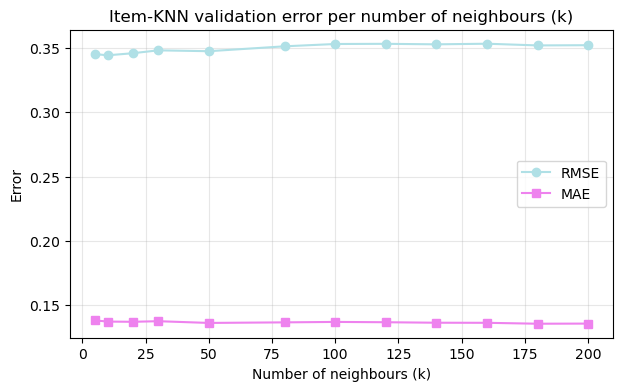

In [30]:
# Plot validation RMSE and MAE against the number of neighbours (k).
plt.figure(figsize=(7, 4))
plt.plot(knn_df['k'], knn_df['val_rmse'], marker='o', color='powderblue', label='RMSE')
plt.plot(knn_df['k'], knn_df['val_mae'], marker='s', color='violet', label='MAE')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('Error')
plt.title('Item-KNN validation error per number of neighbours (k)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The plot makes the pattern visible: the validation RMSE is at its lowest around k=10 and stays nearly flat across the whole range, with only a slight rise for larger k. The MAE line is almost completely flat at about 0.136. Neither curve shows a dip at higher k, which confirms that adding more neighbours does not help the prediction on this data. The flatness reflects the weak neighbour similarities seen earlier: once the few meaningful neighbours are included, extra neighbours carry almost no weight, so the error barely changes. This supports choosing the simplest well-performing option, k=10.

### 4.6 Final model and evaluation on the test set

With the best number of neighbours selected (k=10), the final model is trained on the combined training and validation data and then evaluated on the test set, which was not used during tuning. Combining training and validation gives the final model slightly more data to compute the item similarities from. The same predictive accuracy metrics as before (RMSE and MAE) are reported, so the result can be compared directly with the SVD model.

In [31]:
# Combine training and validation data for the final model.
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

# Rebuild the item-visitor matrix on the combined data.
final_matrix = build_item_user_matrix(train_val_df, n_items, n_users)

# Recompute the item means on the combined data.
final_item_means = np.zeros(n_items, dtype=np.float32)
fmeans = train_val_df.groupby('item_idx')['rating'].mean()
final_item_means[fmeans.index.to_numpy()] = fmeans.to_numpy(dtype=np.float32)

# Mean-center the combined matrix (same vectorized approach as before).
final_centered = final_matrix.copy()
row_index = np.repeat(np.arange(n_items), np.diff(final_centered.indptr))
final_centered.data -= final_item_means[row_index]

# Normalize and fit the final neighbour model with the best k.
final_vectors = normalize(final_centered, norm='l2', axis=1)
final_neighbor_idx, final_neighbor_sim = fit_item_knn(final_vectors, k=best_k_item)

# Visitor-wise view of the combined matrix, for fast lookup during prediction.
final_by_user = final_matrix.T.tocsr()

print("Final Item-KNN model fitted with k =", best_k_item)

Final Item-KNN model fitted with k = 10


In [32]:
# Prediction function for the final model, using the combined-data objects.
def predict_final(user, item, min_neighbors=1):
    neighbors = final_neighbor_idx[item]
    sims = final_neighbor_sim[item]
    user_row = final_by_user[user]
    rated_items = user_row.indices
    rated_values = user_row.data

    num, den, used = 0.0, 0.0, 0
    for nb, sim in zip(neighbors, sims):
        if sim <= 0:
            continue
        pos = np.where(rated_items == nb)[0]
        if len(pos) == 0:
            continue
        rating = rated_values[pos[0]]
        num += sim * (rating - final_item_means[nb])
        den += sim
        used += 1

    if used < min_neighbors or den == 0:
        return float(np.clip(final_item_means[item], 1.0, 3.0))
    return float(np.clip(final_item_means[item] + num / den, 1.0, 3.0))

# Evaluate on the full test set (RMSE and MAE).
test_preds, test_actuals = [], []
for row in test_df.itertuples(index=False):
    test_preds.append(predict_final(int(row.user_idx), int(row.item_idx)))
    test_actuals.append(float(row.rating))

itemknn_rmse = sqrt(mean_squared_error(test_actuals, test_preds))
itemknn_mae = mean_absolute_error(test_actuals, test_preds)

print("Item-KNN test RMSE:", round(itemknn_rmse, 4))
print("Item-KNN test MAE:", round(itemknn_mae, 4))
print("(SVD test RMSE was:", round(svd_rmse, 4), "| MAE:", round(svd_mae, 4), ")")

Item-KNN test RMSE: 0.3275
Item-KNN test MAE: 0.1293
(SVD test RMSE was: 0.2975 | MAE: 0.1315 )


### Interpretation

On the test set, Item-KNN reaches an RMSE of 0.3275 and an MAE of 0.1293. Compared with SVD (RMSE 0.2975, MAE 0.1315), the two models trade places depending on the metric: SVD has the lower RMSE, while Item-KNN has the lower MAE. This split is informative, because RMSE and MAE react differently to the kind of errors each model makes.

Item-KNN has the lower MAE, which means its predictions are on average a bit closer to the true rating. This fits the earlier observation that Item-KNN can predict values well above 1 when an item's neighbours were bought or added to cart, so it captures the rarer deeper events a little better than SVD, which predicted values close to 1 almost everywhere. Item-KNN has the higher RMSE, though. RMSE punishes large errors more heavily, so the occasional confident-but-wrong prediction (for example predicting a value near 3 for an interaction that was actually a view) costs it more. SVD, by predicting cautiously close to 1 for nearly everything, avoids those large individual errors and ends up with the lower RMSE, even though its average error is slightly bigger.

In short, Item-KNN is a bit more willing to predict high ratings and gets rewarded for it in MAE, but punished for its occasional large mistakes in RMSE. This is a real difference in behaviour between a neighbourhood method and a matrix factorization method on this view-dominated data, rather than one model simply being better than the other.

### 4.7 Classification: predicting transactions

The second required evaluation treats Item-KNN as a classification task: instead of predicting the exact rating, the goal is to predict whether an interaction is a transaction. The ground truth is the `purchased` flag created in the EDA notebook (1 for a transaction, 0 otherwise), which is a more direct target than thresholding a rating.

The predicted rating from Item-KNN is used as a score: a higher predicted rating means the model considers a transaction more likely. This score is evaluated in two ways. First, with AUC-ROC, which measures how well the scores separate transactions from the rest across all possible thresholds, without committing to one threshold. Second, by turning the score into a binary prediction with a threshold and computing precision, recall and F1.

The threshold needs more thought than for Diginetica, because the rating scale now has three levels (view 1, add-to-cart 2, transaction 3) instead of two. The positive class is the transaction level specifically, so a threshold of 2.5 is used, sitting between the add-to-cart and transaction levels: only predictions leaning towards the transaction level are classified as a transaction. AUC-ROC remains the primary metric, since it does not depend on this choice.

This is important because the data is highly imbalanced: only about 2% of interactions are transactions. With such imbalance, accuracy is misleading, because always predicting "no transaction" would already be about 98% accurate. Precision, recall, F1 and AUC-ROC are therefore the appropriate metrics, as they focus on how well the rare transaction class is identified (Bhaumik, 2024a).

To make the errors easy to read, a confusion matrix is also reported. It shows how often each true class is predicted correctly or confused with the other: correct predictions lie on the diagonal, while the off-diagonal cells show the two types of mistake (non-transactions wrongly flagged as transactions, and transactions that were missed). The precision and recall above are computed directly from these four counts.

In [33]:
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix)

# Predict a rating (score) for every interaction in the test set.
# This reuses the final model; the higher the score, the more likely a transaction.
test_scores = np.array([predict_final(int(r.user_idx), int(r.item_idx))
                        for r in test_df.itertuples(index=False)])

# The true labels are the purchase flags from the EDA notebook.
test_labels = test_df['purchased'].to_numpy()

print("Test interactions:", len(test_labels))
print("Transactions in test set:", int(test_labels.sum()),
      f"({test_labels.mean():.2%})")

Test interactions: 112059
Transactions in test set: 1977 (1.76%)


In [34]:
# AUC-ROC uses the continuous score directly (no threshold needed).
auc = roc_auc_score(test_labels, test_scores)

# For precision/recall/F1 the score is turned into a 0/1 prediction with a threshold.
# The rating scale is view=1, add-to-cart=2, transaction=3, and the positive class is the transaction.
# A threshold of 2.5 sits between add-to-cart and transaction: a predicted rating above 2.5 is classified as a transaction.
threshold = 2.5
test_pred_class = (test_scores > threshold).astype(int)

precision = precision_score(test_labels, test_pred_class, zero_division=0)
recall = recall_score(test_labels, test_pred_class, zero_division=0)
f1 = f1_score(test_labels, test_pred_class, zero_division=0)

print("AUC-ROC:  ", round(auc, 4))
print("Precision:", round(precision, 4))
print("Recall:   ", round(recall, 4))
print("F1-score: ", round(f1, 4))
print("\nConfusion matrix (rows = true, cols = predicted):")
print(confusion_matrix(test_labels, test_pred_class))

AUC-ROC:   0.6415
Precision: 0.3438
Recall:    0.0389
F1-score:  0.07

Confusion matrix (rows = true, cols = predicted):
[[109935    147]
 [  1900     77]]


### Interpretation

The classification results give a clearer signal than the rating and ranking evaluations did. The AUC-ROC is 0.6415, well above the 0.5 of random guessing, which means the predicted ratings do separate transactions from the rest fairly well across all thresholds. This is the strongest result any of the models produced on a task tied to the rare positive class, and it likely comes from the funnel-based proxy rating: the extra add-to-cart level in the middle seems to give Item-KNN more to work with than a plain view-versus-purchase split would.

The precision, recall and F1 are low, but they only make sense alongside the threshold. At a threshold of 2.5, the model predicts a transaction for just 224 of the 112,059 test interactions (147 + 77 in the confusion matrix), and 77 of those are real transactions, giving a precision of 0.344. Out of the 1,977 real transactions it catches 77, which gives a recall of 0.039 and an F1 of 0.07. In other words, when it does flag a transaction it is right about a third of the time, but with this strict threshold it hardly flags any, so it misses most of them.

The low recall should not be over-read, though. It is mostly caused by the strict threshold rather than weak scores, since the AUC of 0.6415 shows the scores do have real separating power, and a lower threshold would catch more transactions at the cost of precision. The threshold-free AUC is therefore the more useful number here, and on that measure Item-KNN does clearly better than chance, and better than it did on ranking. That is a useful result: once the task is framed as finding the rare transaction class instead of predicting the dominant view rating, the item-based method shows a usable signal, even on this sparse and view-heavy data.

### 4.8 Top-N ranking evaluation

As with SVD, Item-KNN is also evaluated on ranking quality, so the two techniques can be compared on the same basis. The same evaluation function and the same values of K are used: for each sampled test visitor, every item is scored, the held-out test items are treated as relevant, and Precision@K, Recall@K and HitRate@K are computed. Items the visitor already interacted with in training are excluded. This measures whether Item-KNN puts the relevant items near the top of its recommendation list, which is the part of the task that SVD struggled with.

In [35]:
# For scoring, the predicted rating of an item for a visitor is the similarity-weighted average of the visitor's ratings on that item's neighbours (relative to item means).
# This is computed for all items at once, so evaluate_topn stays fast.
final_means = final_item_means

def itemknn_scores(user, items):
    # Ratings this visitor gave, as a dense vector over all items (mostly zero).
    user_row = final_by_user[user]
    rated = np.zeros(n_items, dtype=np.float32)
    rated[user_row.indices] = user_row.data
    # Mask of which items the visitor actually interacted with.
    seen_mask = np.zeros(n_items, dtype=bool)
    seen_mask[user_row.indices] = True

    # For every queried item, gather its k neighbours and their similarities.
    nb = final_neighbor_idx[items]          # shape (len(items), k)
    sim = final_neighbor_sim[items]         # shape (len(items), k)

    # Rating the visitor gave to each neighbour, and whether it interacted with it.
    nb_rating = rated[nb]                   # 0 where not interacted with
    nb_seen = seen_mask[nb]                 # True where the visitor rated the neighbour
    nb_mean = final_means[nb]

    # Only neighbours with positive similarity and interacted with count.
    valid = (sim > 0) & nb_seen
    weighted = np.where(valid, sim * (nb_rating - nb_mean), 0.0).sum(axis=1)
    denom = np.where(valid, sim, 0.0).sum(axis=1)

    # Prediction = item mean + weighted deviation, fall back to item mean if no neighbours.
    out = final_means[items].astype(np.float32).copy()
    nonzero = denom > 0
    out[nonzero] = final_means[items][nonzero] + weighted[nonzero] / denom[nonzero]
    return out

# Run the ranking evaluation at the same K values and sample size as SVD.
print("Item-KNN ranking:")
for K in [10, 20, 50, 100, 200, 500]:
    res = evaluate_topn(itemknn_scores, K=K, n_sample=N_EVAL)
    print(f"K={K:3d} | Precision: {res['precision']:.4f} | "
          f"Recall: {res['recall']:.4f} | HitRate: {res['hitrate']:.4f}")

Item-KNN ranking:
K= 10 | Precision: 0.0000 | Recall: 0.0003 | HitRate: 0.0003
K= 20 | Precision: 0.0000 | Recall: 0.0003 | HitRate: 0.0003
K= 50 | Precision: 0.0000 | Recall: 0.0004 | HitRate: 0.0006
K=100 | Precision: 0.0000 | Recall: 0.0016 | HitRate: 0.0020
K=200 | Precision: 0.0000 | Recall: 0.0032 | HitRate: 0.0037
K=500 | Precision: 0.0000 | Recall: 0.0057 | HitRate: 0.0065


### Interpretation

On ranking, Item-KNN performs at roughly the same weak level as SVD, and clearly below the popularity baseline. Its HitRate rises from 0.0003 at K=10 to 0.0065 at K=500, which is close to SVD (0.0085 at K=500) and SVD++ (0.0106 at K=500), and far below the popularity baseline (0.1175 at K=500). As with SVD, the precision stays at 0.0000 at every K, because with only a few held-out items per visitor and a list that is tiny next to the 65,000-item catalogue, almost none of the top-K slots can be correct; recall and HitRate are the meaningful metrics here. Compared with random guessing (about 0.77% at K=500), all three collaborative filtering models sit at roughly chance level on ranking.

This is a slightly different picture from the rating evaluation, where Item-KNN behaved differently from SVD (lower MAE, higher RMSE). On ranking the two end up very close, and the reason follows directly from section 4.3: the neighbour similarities are extremely weak on this data, with even the closest neighbours barely above zero. With so little similarity signal, the item-based scores cannot order the catalogue in a visitor-specific way any better than the factorization model can, so Item-KNN does not gain the small ranking edge it had on the other dataset. The shared conclusion across all three models is the same: on sparse, view-dominated e-commerce data, ranking the exact held-out item highly is very hard, and a simple popularity rule remains the strongest reference by a wide margin.

### 4.9 Example top-N recommendations

To make the Item-KNN output concrete, the top-10 recommendations are generated for the same two example visitors used for SVD: a randomly chosen visitor and the most active visitor. For each visitor, the items it interacted with in training are shown next to the items Item-KNN recommends, so the two can be compared. As with SVD, the items are anonymized, so each recommendation is shown with its category id for context rather than a product name.

In [36]:
# Recommend the top-K items for a visitor using the Item-KNN scores, excluding items the visitor already interacted with in training.
def recommend_itemknn(user, K=10):
    all_items = np.arange(n_items)
    scores = itemknn_scores(user, all_items)        # score every item

    # Exclude items already seen by this visitor in the combined training data.
    seen = final_by_user[user].indices
    scores[seen] = -np.inf

    # Take the top-K items, highest score first.
    top_k = np.argpartition(-scores, K)[:K]
    return top_k[np.argsort(-scores[top_k])]

def show_user_itemknn(user, K=10):
    # Items the visitor interacted with in the combined training data.
    seen = sorted(final_by_user[user].indices)
    print(f"Visitor {user} interacted with {len(seen)} items in training.")
    print("\nItems this visitor interacted with (first 10):")
    print(describe_items(seen[:10]).to_string(index=False))
    print("\nTop-10 recommendations from Item-KNN:")
    print(describe_items(recommend_itemknn(user, K)).to_string(index=False))

In [37]:
# Example 1: the same random visitor approach as used for SVD.
example_rng = np.random.default_rng(7)
random_user = int(example_rng.choice(test_items_per_user.index.to_numpy()))

print("=== Example 1: random visitor ===")
show_user_itemknn(random_user)

=== Example 1: random visitor ===
Visitor 96656 interacted with 5 items in training.

Items this visitor interacted with (first 10):
 item_idx  item_id category_id
     5890   172293         984
     7990   294242         984
     9540   309652        1197
    16641   183178         984
    29650   392082         984

Top-10 recommendations from Item-KNN:
 item_idx  item_id category_id
    62706   390250        1493
    61888    60080         282
    53912   366238        1163
    54792   384212        1455
    24303   116721         833
    20636    18859        1113
    29135   122984        1493
    19204   212789        1578
    55547   340327         330
    53466    47737         891


### Interpretation

This randomly chosen visitor interacted with five items, four from category 984 and one from category 1197. The ten items Item-KNN recommends come from a wide spread of other categories (1493, 282, 1163, 1455, and so on) and none of them are from category 984 or 1197. So even though Item-KNN uses item similarity, the recommendations for this visitor are not clearly related to the categories it actually interacted with. This is understandable given the weak neighbour similarities seen earlier: with only five interactions and very low similarity scores, there is little reliable signal to base similar-item recommendations on.

In [38]:
# Example 2: the most active visitor (most interactions in training).
most_active_user = int(train_df['user_idx'].value_counts().idxmax())

print("=== Example 2: most active visitor ===")
show_user_itemknn(most_active_user)

=== Example 2: most active visitor ===
Visitor 83857 interacted with 3222 items in training.

Items this visitor interacted with (first 10):
 item_idx  item_id category_id
        7    65273         342
        8   253615         342
       17    38965         858
       20   319680         858
       29   224700         317
       43   291964        1273
       47   134620         589
       51   373637        1051
       52     1152        1051
       55   305656        1051

Top-10 recommendations from Item-KNN:
 item_idx  item_id category_id
     9635    92600         434
    49255   246113        1680
    50792   350645         491
    32293    88577        1171
    16772   236143        1421
    23773    73091         324
    15932   396281         808
    50658    72715         686
    53819   233313         686
    25292   387504        1493


### Interpretation

The most active visitor interacted with 3,222 items, with a clear concentration in category 1051 (three of its first ten items). A method based on item similarity would ideally recommend more items from category 1051 or closely related categories. The top-10 recommendations, however, contain no items from category 1051; they come from a range of unrelated categories (434, 1680, 491, and others).

There is one difference from SVD worth noting. Item-KNN's two recommendation lists are not the same for the two visitors: the random visitor and the most active visitor receive clearly different items, whereas SVD gave both almost the same list. So Item-KNN does make more use of the visitor's history and produces somewhat more visitor-specific lists. Even so, the recommendations still do not reflect this visitor's strong category-1051 preference, and a few broadly well-connected items (such as item 25292 in category 1493, which also appeared in the SVD lists) keep showing up. The likely reason combines the data and the method: with extremely weak neighbour similarities, the prediction step leans on the small number of items that have any non-zero similarity, which tends to surface a handful of generally well-connected items rather than items tailored to the visitor. So Item-KNN is a step more personalized than SVD here, but still falls short of capturing a clear, strong preference on this sparse, view-dominated data.

### 4.10 Comparison of the techniques

This section brings together the results of all models on the test set, so the two techniques (and the SVD++ extension and the popularity baseline) can be compared directly. The comparison covers the predictive accuracy (RMSE and MAE), the ranking quality (HitRate@500 as a representative ranking score), and, for Item-KNN, the classification of transactions (AUC-ROC).

In [39]:
# Collect the main test-set results of all models into one comparison table.
# Ranking is summarized by HitRate@500 (the widest K used in the ranking evaluation).
comparison = pd.DataFrame([
    {'Model': 'SVD',        'Test RMSE': round(svd_rmse, 4),     'Test MAE': round(svd_mae, 4),     'HitRate@500': 0.0085, 'AUC-ROC': None},
    {'Model': 'SVD++',      'Test RMSE': round(svdpp_rmse, 4),   'Test MAE': round(svdpp_mae, 4),   'HitRate@500': 0.0106, 'AUC-ROC': None},
    {'Model': 'Item-KNN',   'Test RMSE': round(itemknn_rmse, 4), 'Test MAE': round(itemknn_mae, 4), 'HitRate@500': 0.0065, 'AUC-ROC': round(auc, 4)},
    {'Model': 'Popularity', 'Test RMSE': None,                   'Test MAE': None,                  'HitRate@500': 0.1175, 'AUC-ROC': None},
])

print(comparison.to_string(index=False))

     Model  Test RMSE  Test MAE  HitRate@500  AUC-ROC
       SVD     0.2975    0.1315       0.0085      NaN
     SVD++     0.2978    0.1332       0.0106      NaN
  Item-KNN     0.3275    0.1293       0.0065   0.6415
Popularity        NaN       NaN       0.1175      NaN


### 4.11 Conclusion: Item-KNN

Of the two techniques, Item-KNN is the one that gave me the most interesting result on this dataset, even though its overall numbers are modest. Built from scratch with mean-centering, cosine similarity and a similarity-weighted neighbourhood prediction (k=10 neighbours, tuned on validation), it was evaluated as both a rating predictor and a classifier.

On rating prediction it traded places with SVD: a slightly higher RMSE (0.3275) but a lower MAE (0.1293), because it is more willing to predict above the view level. On ranking it stayed weak, level with SVD (HitRate@500 of 0.0065) and well behind the popularity baseline, and the example recommendations were only a little more visitor-specific than SVD's. The standout, though, was classification: an AUC-ROC of 0.6415, clearly above random and the best signal any model produced on a task tied to the rare positive class. The low precision and recall at threshold 2.5 look worse than they are, since the threshold-free AUC shows the scores really do separate transactions from the rest.

So, the picture is mixed but with a clear bright spot. As a recommender that ranks or personalizes, Item-KNN is held back by the same thin, view-heavy data as SVD, and its weak neighbour similarities leave it little to work with. But once the question becomes "is this a transaction?" rather than "what rating?", the item-based scores carry a usable signal. That contrast, weak on ranking but useful on classification, is the main thing I take away from technique D here.

## 5. Overall conclusion between both data sets

Because this is the second of the two datasets, the most useful thing to do here is compare. Both Diginetica and Retail Rocket were run through the same from-scratch pipeline, SVD with the SVD++ bonus and Item-KNN, and on the big picture they behave the same way. On both, the models predict the proxy rating accurately (RMSE around 0.30 and MAE around 0.13 here), but that accuracy is mostly an artefact of how dominant views are. On both, ranking collapses to roughly random and loses to a simple popularity baseline, and on both, SVD++ adds almost nothing over plain SVD. The shared lesson is the one that runs through both notebooks: on sparse, view-dominated data a low rating error does not mean good recommendations, more complexity is not a fix, and the metric you choose decides what story you see.

Where the two datasets genuinely differ is classification, and that difference is the most interesting result of the whole project. Catching the rare positive class worked clearly better on Retail Rocket (AUC-ROC 0.6415) than on Diginetica (around 0.55). I think the reason is the feedback itself: Retail Rocket records a three-step funnel (view, add-to-cart, transaction), so its proxy rating has a middle level that Diginetica's view-versus-purchase split does not, and that extra level gives the model more to separate transactions from everything else. The slightly higher rating errors on Retail Rocket fit the same idea, since the add-to-cart level means more ratings really do differ from 1. In other words, the richer the feedback, the more even a simple method has to work with.

That points straight at the most promising next step: stop predicting a proxy rating and treat the task as implicit-feedback ranking from the start, so the objective matches the real goal of surfacing relevant items. A time-based split (earlier weeks to train, later weeks to test) would be more realistic than the random per-visitor split, and a candidate-generation stage could make the ranking evaluation cheaper, though I deliberately avoided that because restricting candidates to popular items would inflate the hit rate and break the comparison between models. All three point the same way: across both datasets, the bottleneck is the nature of the feedback, not the technique.

## 6. References

Bhaumik, D. (2024a). RecSys – Basic Techniques [Lecture slides]. Amsterdam University of Applied Sciences.

Bhaumik, D. (2024b). RecSys – Techniques 2 [Lecture slides]. Amsterdam University of Applied Sciences.

Ji, Y., Sun, A., Zhang, J., & Li, C. (2020). A re-visit of the popularity baseline in recommender systems. In *Proceedings of the 43rd International ACM SIGIR Conference on Research and Development in Information Retrieval* (pp. 1749–1752). https://doi.org/10.1145/3397271.3401233

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263

## Use of AI Tools

AI tools were used in a supporting role only, not to generate the solution. They were consulted to clarify recommender system concepts, to help with debugging, to explain how certain methods or libraries work when needed, and to help make sure that the interpretations and the steps taken were worded clearly and correctly. 